# Explore Model Disagreements

Interactive notebook for exploring disagreements between models across different call types.

**Features:**
- Interactive heatmap of agreement rates
- Filter disagreements by call type and model pair
- View full input/output for specific disagreement cases
- Side-by-side comparison of model responses

In [1]:
import json
import sys
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML, Markdown
import pandas as pd

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent.parent))

from experiments.compare_models.core.registry import CallTypeRegistry
import experiments.compare_models.handlers

# Configure plotting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("✓ Imports complete")

/Users/abuonomo/Library/Caches/pypoetry/virtualenvs/paper-data-linking-GXZ7GlHC-py3.10/lib/python3.10/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'fields' has been removed
  warnings.warn(message, UserWarning)


✓ Imports complete


## 1. Configure Experiment

In [2]:
# Configure experiment directory
EXPERIMENT_NAME = "full_comparison_20251029"
EXPERIMENT_DIR = Path("prompt_experiments") / EXPERIMENT_NAME

print(f"Analyzing experiment: {EXPERIMENT_NAME}")
print(f"Directory: {EXPERIMENT_DIR}")

if not EXPERIMENT_DIR.exists():
    print(f"\n⚠️  ERROR: Directory not found: {EXPERIMENT_DIR}")
else:
    result_files = list(EXPERIMENT_DIR.glob("*.jsonl"))
    print(f"\n✓ Found {len(result_files)} result files")

Analyzing experiment: full_comparison_20251029
Directory: prompt_experiments/full_comparison_20251029

✓ Found 30 result files


## 2. Load All Results

In [3]:
def load_jsonl(file_path):
    """Load JSONL file into list of dicts."""
    results = []
    with open(file_path) as f:
        for line in f:
            if line.strip():
                results.append(json.loads(line))
    return results

# Load all results grouped by call_type and model
all_results = defaultdict(lambda: defaultdict(list))

result_files = sorted(EXPERIMENT_DIR.glob("*.jsonl"))

for result_file in result_files:
    results = load_jsonl(result_file)
    if not results:
        continue
    
    call_type = results[0].get('call_type')
    model_name = results[0].get('model_name')
    
    if not call_type or not model_name:
        continue
    
    all_results[call_type][model_name] = results

# Get all models and call types
all_models = set()
for call_type_results in all_results.values():
    all_models.update(call_type_results.keys())
all_models = sorted(all_models)

all_call_types = sorted(all_results.keys())

print(f"Loaded {len(all_call_types)} call types:")
for ct in all_call_types:
    print(f"  - {ct}")
print(f"\nLoaded {len(all_models)} models:")
for m in all_models:
    print(f"  - {m}")

Loaded 10 call types:
  - cadence_normalization
  - detector_normalization
  - instrument_selection
  - instrument_validation
  - mission_identification
  - mission_selection
  - physobs_normalization
  - structure_analysis
  - time_normalization
  - wavelength_normalization

Loaded 3 models:
  - openai/gpt-5
  - openai/gpt-5-mini
  - openai/gpt-5-nano


## 3. Calculate Agreement Matrix & Collect Disagreements

In [4]:
# Calculate agreement rates and collect all disagreement cases
agreement_data = []
all_disagreements = defaultdict(lambda: defaultdict(list))  # [call_type][model_pair] = [cases]

for call_type in all_call_types:
    model_results = all_results[call_type]
    
    # Get handler
    try:
        handler = CallTypeRegistry.get(call_type)
    except KeyError:
        print(f"Warning: No handler for {call_type}, skipping")
        continue
    
    models = sorted(model_results.keys())
    
    # Calculate pairwise agreements and collect disagreements
    for i, model1 in enumerate(models):
        for model2 in models[i+1:]:
            results1 = model_results[model1]
            results2 = model_results[model2]
            
            agreements = 0
            disagreements_list = []
            total = 0
            
            for r1 in results1:
                case_idx = r1['case_index']
                r2 = next((r for r in results2 if r['case_index'] == case_idx), None)
                
                if r2 is None:
                    continue
                
                parsed1 = r1.get('parsed_response')
                parsed2 = r2.get('parsed_response')
                
                if parsed1 is None or parsed2 is None:
                    continue
                
                total += 1
                
                try:
                    comparison = handler.compare_responses(parsed1, parsed2)
                    if comparison.agree:
                        agreements += 1
                    else:
                        # Store disagreement
                        disagreements_list.append({
                            'case_index': case_idx,
                            'original_id': r1.get('original_id'),
                            'model1_data': r1,
                            'model2_data': r2,
                            'comparison_details': comparison.details
                        })
                except Exception as e:
                    continue
            
            if total > 0:
                agreement_rate = agreements / total * 100
                
                m1_short = model1.split('/')[-1]
                m2_short = model2.split('/')[-1]
                model_pair = f"{m1_short} vs {m2_short}"
                
                agreement_data.append({
                    'call_type': call_type,
                    'model_pair': model_pair,
                    'model1': model1,
                    'model2': model2,
                    'model1_short': m1_short,
                    'model2_short': m2_short,
                    'agreement_rate': agreement_rate,
                    'total_cases': total,
                    'num_disagreements': len(disagreements_list)
                })
                
                # Store disagreements for later exploration
                all_disagreements[call_type][model_pair] = disagreements_list

print(f"✓ Calculated agreement for {len(agreement_data)} model pair × call type combinations")
print(f"✓ Collected disagreements for interactive exploration")

✓ Calculated agreement for 30 model pair × call type combinations
✓ Collected disagreements for interactive exploration


## 4. Interactive Heatmap

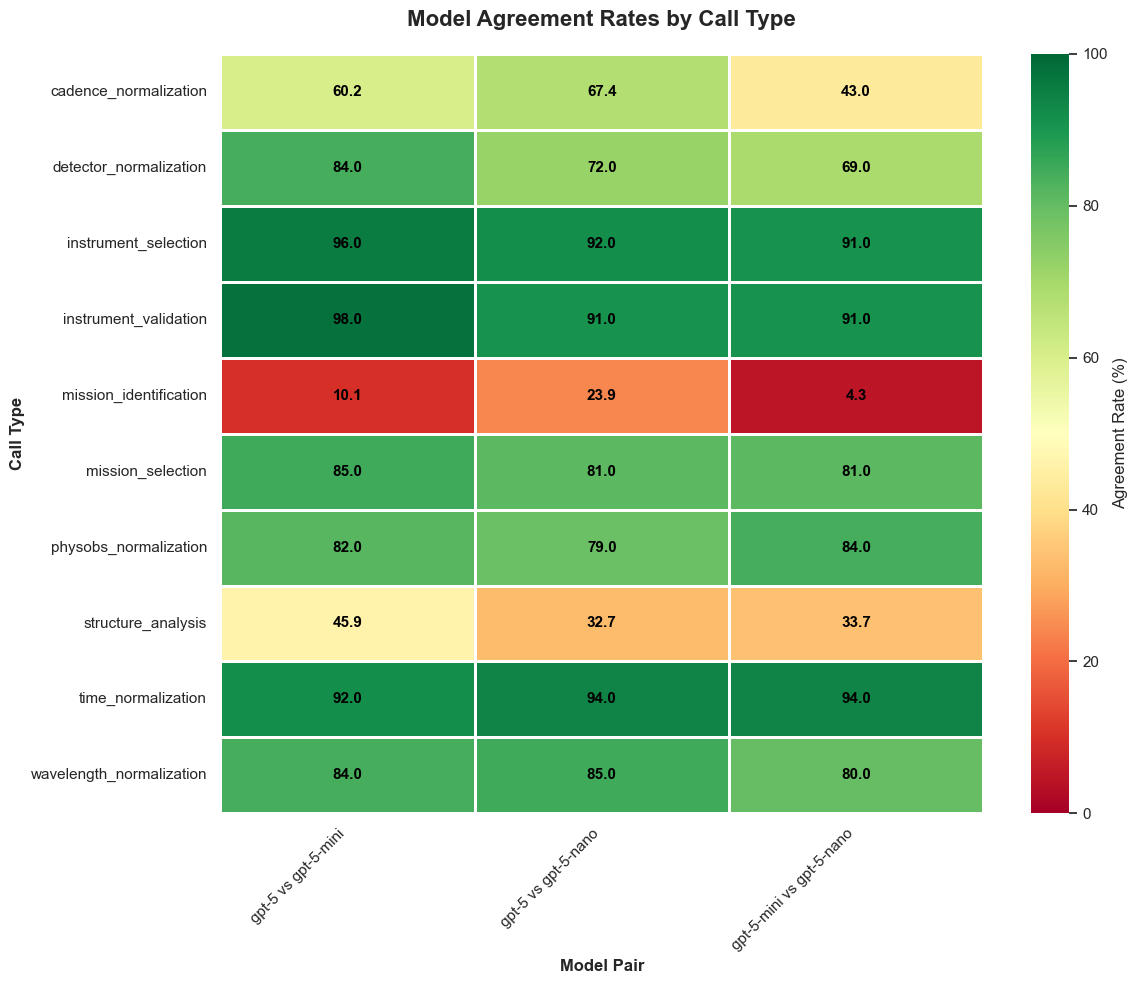


💡 TIP: Use the cells below to explore specific disagreements from this heatmap


In [16]:
# Create interactive heatmap
call_types = sorted(set(d['call_type'] for d in agreement_data))
model_pairs = sorted(set(d['model_pair'] for d in agreement_data))

heatmap_data = np.zeros((len(call_types), len(model_pairs)))

for i, call_type in enumerate(call_types):
    for j, model_pair in enumerate(model_pairs):
        match = next((d for d in agreement_data 
                     if d['call_type'] == call_type and d['model_pair'] == model_pair), None)
        if match:
            heatmap_data[i, j] = match['agreement_rate']

fig, ax = plt.subplots(figsize=(12, 10))

# Draw heatmap WITHOUT annotations first
sns.heatmap(heatmap_data,
            xticklabels=model_pairs,
            yticklabels=call_types,
            annot=False,  # Turn off seaborn's annotation
            cmap='RdYlGn',
            vmin=0,
            vmax=100,
            cbar_kws={'label': 'Agreement Rate (%)'},
            linewidths=1,
            linecolor='white',
            ax=ax)

# Manually add text annotations
for i in range(len(call_types)):
    for j in range(len(model_pairs)):
        value = heatmap_data[i, j]
        if value > 0:  # Only annotate if there's data
            # Choose text color based on value
            text_color = 'black'
            ax.text(j + 0.5, i + 0.5, f'{value:.1f}',
                   ha='center', va='center',
                   color=text_color,
                   fontsize=11,
                   fontweight='bold')

plt.title('Model Agreement Rates by Call Type', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Model Pair', fontsize=12, fontweight='bold')
plt.ylabel('Call Type', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 TIP: Use the cells below to explore specific disagreements from this heatmap")

## 5. Filter Disagreements (Configure Here)

In [57]:
# ========== CONFIGURE THESE PARAMETERS ==========

# Select call type to explore
SELECTED_CALL_TYPE = "detector_normalization"  # Change this!

# Select model pair to compare
SELECTED_MODEL_PAIR = "gpt-5 vs gpt-5-mini"  # Change this!
# Options: "gpt-5 vs gpt-5-mini", "gpt-5 vs gpt-5-nano", "gpt-5-mini vs gpt-5-nano"

# =================================================

# Validate selections
if SELECTED_CALL_TYPE not in all_call_types:
    print(f"⚠️  ERROR: Call type '{SELECTED_CALL_TYPE}' not found!")
    print(f"Available call types: {all_call_types}")
else:
    disagreements = all_disagreements[SELECTED_CALL_TYPE].get(SELECTED_MODEL_PAIR, [])
    
    print(f"✓ Selected: {SELECTED_CALL_TYPE}")
    print(f"✓ Model Pair: {SELECTED_MODEL_PAIR}")
    print(f"✓ Found {len(disagreements)} disagreement cases")
    
    if disagreements:
        print(f"\n📊 Disagreement case indices: {[d['case_index'] for d in disagreements[:10]]}...")
    else:
        print("\n⚠️  No disagreements found for this combination!")

✓ Selected: detector_normalization
✓ Model Pair: gpt-5 vs gpt-5-mini
✓ Found 16 disagreement cases

📊 Disagreement case indices: [14, 16, 17, 35, 50, 67, 69, 73, 75, 77]...


## 6. Browse Disagreement Cases

In [58]:
# List all disagreement cases with summaries
if disagreements:
    handler = CallTypeRegistry.get(SELECTED_CALL_TYPE)
    
    print(f"Disagreement Cases for {SELECTED_CALL_TYPE} ({SELECTED_MODEL_PAIR})")
    print("="*100)
    
    for i, d in enumerate(disagreements, 1):
        case_idx = d['case_index']
        r1 = d['model1_data']
        r2 = d['model2_data']
        
        summary1 = handler.get_short_summary(r1.get('parsed_response'))
        summary2 = handler.get_short_summary(r2.get('parsed_response'))
        
        print(f"\n{i}. Case {case_idx} (ID: {d['original_id'][:8]}...)")
        print(f"   {r1['model_name'].split('/')[-1]}: {summary1}")
        print(f"   {r2['model_name'].split('/')[-1]}: {summary2}")
        
        if d.get('comparison_details'):
            print(f"   Details: {d['comparison_details']}")
else:
    print("No disagreements to display.")

Disagreement Cases for detector_normalization (gpt-5 vs gpt-5-mini)

1. Case 14 (ID: 71478334...)
   gpt-5: NULL
   gpt-5-mini: "C2"
   Details: Response 1: null | Response 2: C2 | Exact match: False

2. Case 16 (ID: 546006da...)
   gpt-5: NULL
   gpt-5-mini: "C2"
   Details: Response 1: null | Response 2: C2 | Exact match: False

3. Case 17 (ID: 04ff91b4...)
   gpt-5: "C2"
   gpt-5-mini: "C2}{"
   Details: Response 1: C2 | Response 2: C2}{ | Exact match: False

4. Case 35 (ID: 9287208c...)
   gpt-5: NULL
   gpt-5-mini: "A"
   Details: Response 1: null | Response 2: A | Exact match: False

5. Case 50 (ID: 31a5f4be...)
   gpt-5: "C2"
   gpt-5-mini: "C2}{"
   Details: Response 1: C2 | Response 2: C2}{ | Exact match: False

6. Case 67 (ID: b3c13cab...)
   gpt-5: NULL
   gpt-5-mini: "C2"
   Details: Response 1: null | Response 2: C2 | Exact match: False

7. Case 69 (ID: bb50da17...)
   gpt-5: "COR1"
   gpt-5-mini: "COR1'}{"
   Details: Response 1: COR1 | Response 2: COR1'}{ | Exact match: 

## 7. Deep Dive: Inspect Specific Case

In [110]:
# ========== SELECT CASE INDEX ==========
CASE_TO_INSPECT = 17  # Change this to the case_index you want to examine
# =======================================

# Find the disagreement
selected_disagreement = None
for d in disagreements:
    if d['case_index'] == CASE_TO_INSPECT:
        selected_disagreement = d
        break

if selected_disagreement:
    r1 = selected_disagreement['model1_data']
    r2 = selected_disagreement['model2_data']
    
    print(f"{'='*100}")
    print(f"CASE {CASE_TO_INSPECT} - DETAILED COMPARISON")
    print(f"{'='*100}")
    print(f"Original ID: {selected_disagreement['original_id']}")
    print(f"Call Type: {SELECTED_CALL_TYPE}")
    print(f"\nComparison Details: {selected_disagreement.get('comparison_details', 'N/A')}")
else:
    print(f"⚠️  Case {CASE_TO_INSPECT} not found in disagreements")
    if disagreements:
        print(f"Available case indices: {[d['case_index'] for d in disagreements]}")

CASE 17 - DETAILED COMPARISON
Original ID: 04ff91b4-3b3f-44f7-b0fb-13eff036a47d
Call Type: detector_normalization

Comparison Details: Response 1: C2 | Response 2: C2}{ | Exact match: False


### 7.1 View User Prompt (Input)

In [111]:
if selected_disagreement:
    r1 = selected_disagreement['model1_data']
    
    # Extract user message
    user_msg = None
    for msg in r1.get('input_messages', []):
        if msg.get('role') == 'user':
            user_msg = msg.get('content')
            break
    
    if user_msg:
        print("USER PROMPT (sent to both models):")
        print("="*100)
        print(user_msg)
    else:
        print("⚠️  No user message found")

USER PROMPT (sent to both models):
<user_prompt>
  The following detectors are the _only_ valid options for instrument LASCO:

  ['C1', 'C2', 'C3']

  Given the paper context:
  "Used to observe CME leading edges and to extract height–time measurements (via the CME Catalog) for shock-PL fits relating CME envelopes to shock fronts. CME leading edge/front"

  Choose exactly one of the above detector options, or return null if none fits. Respond with a JSON object:
  {"detector": &lt;one of the listed values or null&gt;}
</user_prompt>


### 7.2 Side-by-Side Model Outputs

In [109]:
if selected_disagreement:
    r1 = selected_disagreement['model1_data']
    r2 = selected_disagreement['model2_data']
    
    model1_name = r1['model_name'].split('/')[-1]
    model2_name = r2['model_name'].split('/')[-1]
    
    print(f"\n{'='*100}")
    print(f"MODEL OUTPUTS - SIDE BY SIDE")
    print(f"{'='*100}\n")
    
    # Show raw outputs using HTML for better side-by-side display
    output1 = r1.get('output_content', 'N/A')
    output2 = r2.get('output_content', 'N/A')
    
    # Use HTML for nice side-by-side with wrapping
    html = f"""
    <div style="display: flex; gap: 20px;">
        <div style="flex: 1; border: 2px solid #4CAF50; padding: 10px; border-radius: 5px;">
            <h3 style="margin-top: 0; color: #4CAF50;">{model1_name.upper()}</h3>
            <pre style="white-space: pre-wrap; word-wrap: break-word; font-family: monospace; font-size: 12px;">{output1}</pre>
        </div>
        <div style="flex: 1; border: 2px solid #2196F3; padding: 10px; border-radius: 5px;">
            <h3 style="margin-top: 0; color: #2196F3;">{model2_name.upper()}</h3>
            <pre style="white-space: pre-wrap; word-wrap: break-word; font-family: monospace; font-size: 12px;">{output2}</pre>
        </div>
    </div>
    """
    
    display(HTML(html))
    
    # Show metrics comparison below
    print(f"\n{'='*100}")
    print("METRICS COMPARISON")
    print(f"{'='*100}")
    
    metrics = [
        ('Cost', f"${r1.get('estimated_cost_usd', 0):.6f}", f"${r2.get('estimated_cost_usd', 0):.6f}"),
        ('Total Tokens', f"{r1.get('total_tokens', 0):,}", f"{r2.get('total_tokens', 0):,}"),
        ('Prompt Tokens', f"{r1.get('prompt_tokens', 0):,}", f"{r2.get('prompt_tokens', 0):,}"),
        ('Completion Tokens', f"{r1.get('completion_tokens', 0):,}", f"{r2.get('completion_tokens', 0):,}"),
        ('Duration (ms)', f"{r1.get('duration_ms', 0):,}", f"{r2.get('duration_ms', 0):,}")
    ]
    
    print(f"\n{model1_name:^45s} | {model2_name:^45s}")
    print(f"{'-'*45}|{'-'*45}")
    for metric_name, val1, val2 in metrics:
        print(f"{metric_name:20s}: {val1:>20s} | {val2:>20s}")


MODEL OUTPUTS - SIDE BY SIDE




METRICS COMPARISON

                    gpt-5                     |                  gpt-5-mini                  
---------------------------------------------|---------------------------------------------
Cost                :            $0.011356 |            $0.001121
Total Tokens        :                1,630 |                1,055
Prompt Tokens       :                  565 |                  565
Completion Tokens   :                1,065 |                  490
Duration (ms)       :               22,121 |               18,895


### 
7.3 Parsed Response Comparison

In [44]:
if selected_disagreement:
    r1 = selected_disagreement['model1_data']
    r2 = selected_disagreement['model2_data']
    
    model1_name = r1['model_name'].split('/')[-1]
    model2_name = r2['model_name'].split('/')[-1]
    
    print(f"\n{'='*100}")
    print(f"PARSED RESPONSES")
    print(f"{'='*100}\n")
    
    print(f"📄 {model1_name.upper()}:")
    print("-" * 100)
    print(json.dumps(r1.get('parsed_response'), indent=2))
    
    print(f"\n\n📄 {model2_name.upper()}:")
    print("-" * 100)
    print(json.dumps(r2.get('parsed_response'), indent=2))

## 8. Quick Statistics

In [ ]:
# Show quick stats for current selection
if disagreements:
    print(f"Statistics for {SELECTED_CALL_TYPE} - {SELECTED_MODEL_PAIR}")
    print("="*80)
    
    # Get the agreement data entry
    stats = next((d for d in agreement_data 
                 if d['call_type'] == SELECTED_CALL_TYPE and d['model_pair'] == SELECTED_MODEL_PAIR), None)
    
    if stats:
        print(f"Total cases compared: {stats['total_cases']}")
        print(f"Agreement rate: {stats['agreement_rate']:.1f}%")
        print(f"Number of disagreements: {stats['num_disagreements']}")
        print(f"Disagreement rate: {100 - stats['agreement_rate']:.1f}%")

## 9. Export Disagreements to JSON

In [ ]:
# Export current selection to JSON file for further analysis
if disagreements:
    output_file = EXPERIMENT_DIR / f"disagreements_{SELECTED_CALL_TYPE}_{SELECTED_MODEL_PAIR.replace(' ', '_')}.json"
    
    export_data = {
        'experiment_name': EXPERIMENT_NAME,
        'call_type': SELECTED_CALL_TYPE,
        'model_pair': SELECTED_MODEL_PAIR,
        'total_disagreements': len(disagreements),
        'disagreements': disagreements
    }
    
    with open(output_file, 'w') as f:
        json.dump(export_data, f, indent=2)
    
    print(f"✓ Exported {len(disagreements)} disagreements to: {output_file}")
else:
    print("No disagreements to export")

## 💡 Usage Guide

**Workflow:**
1. Run cells 1-4 to load data and see the heatmap
2. In cell 5, configure `SELECTED_CALL_TYPE` and `SELECTED_MODEL_PAIR` based on what you want to explore
3. Run cell 6 to see a list of all disagreement cases
4. In cell 7, set `CASE_TO_INSPECT` to a specific case index
5. Run cells 7.1-7.3 to see full details for that case

**Tips:**
- Start with call types that have low agreement (red cells in heatmap)
- Compare gpt-5 vs nano first to see maximum differences
- Use the parsed response view to understand structural differences
- Export disagreements for offline analysis or sharing